<a href="https://colab.research.google.com/github/grigroman2011-oss/cepheid-research/blob/main/cepheid_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install -q astroquery

In [19]:
import astropy.units as u
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
query = """
SELECT TOP 500
  c.source_id,
  g.ra,
  g.dec,
  g.parallax,
  g.parallax_error,
  c.int_average_g,
  c.pf
FROM gaiadr3.vari_cepheid AS c
JOIN gaiadr3.gaia_source AS g ON c.source_id = g.source_id
WHERE c.pf IS NOT NULL
  AND g.parallax IS NOT NULL
  AND g.parallax > 0
"""
job = Gaia.launch_job(query)
r = job.get_results()
df = r.to_pandas()
print(f"Successfully downloaded {len(df)} objects")
df.head()

Successfully downloaded 500 objects


,source_id,ra,dec,parallax,parallax_error,int_average_g,pf
0,4658046002872198528,82.339328,-69.466548,0.007097,0.025093,15.250639,4.684898
1,4658073348979181440,81.330432,-69.451448,0.005862,0.040026,16.606218,1.874496
2,4659178809028714880,89.085242,-67.764603,0.000278,0.030950,15.813277,2.444182
3,4659249246494771840,87.781834,-67.417506,0.052960,0.024813,15.086317,5.506210
4,2021445908555851264,293.887245,25.167609,0.079132,0.077090,17.376587,2.985945


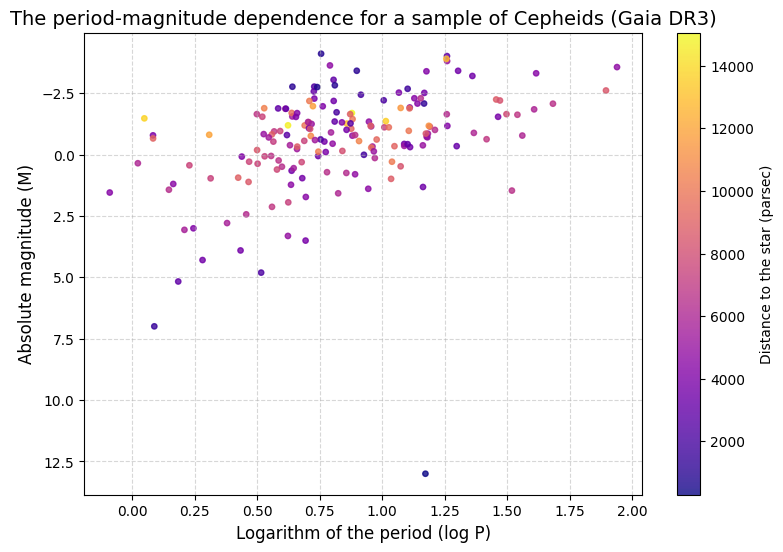

In [21]:
df['distance_pc'] = 1000.0 / df['parallax']
df_clean = df[(df['parallax'] / df['parallax_error'] > 3.3) & (df['distance_pc'] < 50000)].copy()
df_clean['M'] = df_clean['int_average_g'] - 5 * np.log10(df_clean['distance_pc']) + 5
df_clean['log_period'] = np.log10(df_clean['pf'])
plt.figure(figsize=(9, 6))
plt.scatter(df_clean['log_period'], df_clean['M'], c=df_clean['distance_pc'], cmap='plasma', s=15, alpha=0.8)
plt.colorbar(label='Distance to the star (parsec)')
plt.gca().invert_yaxis()
plt.xlabel('Logarithm of the period (log P)', fontsize=12)
plt.ylabel('Absolute magnitude (M)', fontsize=12)
plt.title('The period-magnitude dependence for a sample of Cepheids (Gaia DR3)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()